![PNS](http://caillau.perso.math.cnrs.fr/logo-pns.png)
## MAM5-INUM - Commande optimale
# TP 1 - Navigation problem (a.k.a. Zermelo-Markov-Dubins)
### Special thanks: P. Negre & M. Sadak (Polytech Nice Sophia)

One considers a ship in a constant current, $0 \leq w \lt 1$. The angle of the velocity (*wrt.* to the water) is controlled, leading to the following dynamics:

$$ \begin{array}{rcl}
     \dot{x}(t) &=& w+\cos\theta(t),\quad t \in [0,t_f]\\
     \dot{y}(t) &=& \sin\theta(t),\\
     \dot{\theta}(t) &=& u(t). 
   \end{array} $$

The turning rate (= curvature of turns) is limited, so $|u(t)| \leq 1$. There boundary conditions at $t=0$ and $t=t_f$ on the position $(x,y)$ and on the angle $\theta$ of the velocity in the water referential. The final time is to be minimised. The problem originates from a collaboration with the French company [CGG](https://www.cgg.com) that is interested in optimal maneuvers for very large ships doing marine prospection.

![ship](ship.png)

In [1]:
#JuMP model, Ipopt solver
using JuMP, Ipopt, Plots

sys = Model(optimizer_with_attributes(Ipopt.Optimizer,"print_level"=> 5))
set_optimizer_attribute(sys, "tol", 1e-8)
set_optimizer_attribute(sys, "max_iter", 500)

# Parameters
w = 0.3
x0 = 0 
y0 = 0 
θ0 = π/7
xf = 4
yf = 7
θf =-π/2 
P = 100
Δt = 1/P

# Bounds for variables

@variables(sys,begin
    x[1:3, 1:P]           # x 
    y[1:3, 1:P]           # y 
    θ[1:3, 1:P]           # theta
    -1 ≤ u[1:3] ≤ 1       # u1 à u3, piecewise constant control
     0 ≤ τ[1:3]           # tau1 à tau3, length of subintervals
    end)

# Objective
@objective(sys, Min, τ[1]+τ[2]+τ[3])

# Constraints 
@constraints(sys, begin
    x[1, 1] == x0
    y[1, 1] == y0
    θ[1, 1] == θ0
    x[2, 1] == x[1, P]
    y[2, 1] == y[1, P]
    θ[2, 1] == θ[1, P]
    x[3, 1] == x[2, P]
    y[3, 1] == y[2, P]
    θ[3, 1] == θ[2, P]
    x[3, P] == xf
    y[3, P] == yf
    θ[3, P] == θf
    end)

# Dynamics: Crank-Nicolson scheme
for j in 1 : P-1
    @NLconstraints(sys, begin
        # x' = w + cos(theta)
        x[1, j+1] == x[1, j] + 0.5 * τ[1]*Δt * ( w + cos(θ[1, j]) + w + cos(θ[1, j+1]) )
        x[2, j+1] == x[2, j] + 0.5 * τ[2]*Δt * ( w + cos(θ[2, j]) + w + cos(θ[2, j+1]) )
        x[3, j+1] == x[3, j] + 0.5 * τ[3]*Δt * ( w + cos(θ[3, j]) + w + cos(θ[3, j+1]) )
        # y' = sin(theta) 
        y[1, j+1] == y[1, j] + 0.5 * τ[1]*Δt * ( sin(θ[1, j]) + sin(θ[1, j+1]) )
        y[2, j+1] == y[2, j] + 0.5 * τ[2]*Δt * ( sin(θ[2, j]) + sin(θ[2, j+1]) )
        y[3, j+1] == y[3, j] + 0.5 * τ[3]*Δt * ( sin(θ[3, j]) + sin(θ[3, j+1]) )
        # theta' = u
        θ[1, j+1] == θ[1, j] +       τ[1]*Δt * u[1]
        θ[2, j+1] == θ[2, j] +       τ[2]*Δt * u[2]
        θ[3, j+1] == θ[3, j] +       τ[3]*Δt * u[3]
    end)
end

In [2]:
# Solves for the control and state
println("Solving...")
status = optimize!(sys)
println("Solver status: ", termination_status(sys))
x1 = value.(x)'[:]
y1 = value.(y)'[:]
θ1 = value.(θ)'[:]
u1 = [ value.(u)[1]*ones(P); value.(u)[2]*ones(P); value.(u)[3]*ones(P) ]
τ1 = value.(τ)
println("Cost: " , objective_value(sys))
println("tf: ", τ1[1]+τ1[2]+τ1[3], "\t τ: ", τ1)

Solving...

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.4, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     4176
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:     4455

Total number of variables............................:      906
                     variables with only lower bounds:        3
                variables with lower and upper bounds:        3
                     variables with only upper bounds:        0
Total number of equality constraints.................:      903
Total number of in

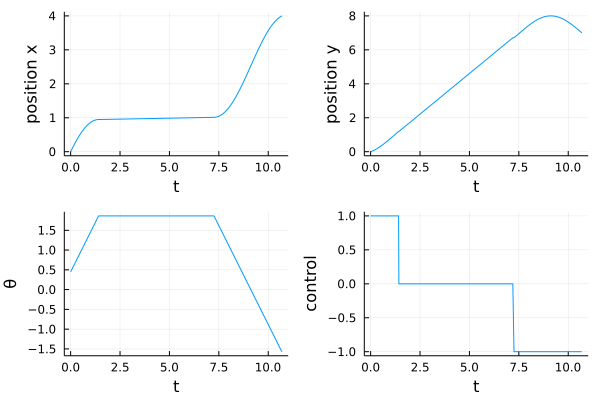

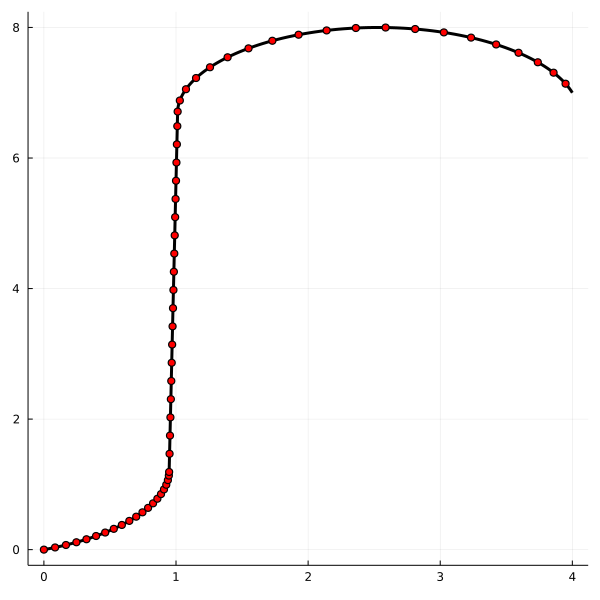

In [3]:
# Plots: states and control
t = zeros(3*P)
t[1:P] = τ1[1]*(0:P-1)
t[P+1:2*P] = P*τ1[1] .+ τ1[2]*(0:P-1)
t[2*P+1:3*P] = P*(τ1[1]+τ1[2]) .+ τ1[3]*(0:P-1)
t = Δt * t
x_plot = plot(t, x1, xlabel = "t", ylabel = "position x", legend = false, fmt = :png)
y_plot = plot(t, y1, xlabel = "t", ylabel = "position y", legend = false, fmt = :png)
θ_plot = plot(t, θ1, xlabel = "t", ylabel = "θ", legend = false, fmt = :png)
u_plot = plot(t, u1, xlabel = "t", ylabel = "control", legend = false, fmt = :png)
display(plot(x_plot, y_plot, θ_plot, u_plot, layout = (2,2)))

# Plots: trajectory 
traj_plot = plot(x1, y1, color = :black, lw = 3)
plot!(size=(600,600))

for i = 1:5:3*P 
    z = [x1[i] y1[i]]
    plot!([z[1]], [z[2]], seriestype = :scatter, color =:red, legend = false) 
    plot!(size=(600,600))
end
current()